# EfficientNetB0 - Augmented

In [1]:
import tensorflow as tf
import keras
from tensorflow.keras import layers, optimizers, metrics, regularizers
from tensorflow import data as tf_data
import numpy as np
import pickle
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from keras.saving import register_keras_serializable

2025-07-30 11:12:26.930751: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-30 11:12:26.932363: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 11:12:26.942051: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 11:12:26.959125: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753891946.982979   12709 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753891946.98

# Data Augmentation and Preprocessing

In [2]:
# Setting some variables 
image_size = (224, 224)
batch_size = 10
seed = 42
    
train_augmentation = keras.Sequential([
    layers.Rescaling(1./255),                       # Normalized pixels to [0,1]
    layers.RandomRotation(0.05),                    # Rotate by 5% of 360 degrees 
    layers.RandomZoom(-0.1, 0.1),                   # Zoom in/out 10%
    layers.RandomFlip("horizontal")                 # Randomly flip images horizontally
])

valid_augmentation = keras.Sequential([
    layers.Rescaling(1./255),])                        # Normalized pixels to [0,1]

train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    batch_size=batch_size,
    image_size=image_size,
    color_mode="grayscale",
    shuffle=True,
    seed=seed,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    "valid",
    batch_size=batch_size,
    image_size=image_size,
    color_mode="grayscale",
    shuffle=False,
    seed=seed,
)

AUTOTUNE = tf.data.AUTOTUNE

# Apply augmentations to training data 
train_ds = train_ds.map(lambda x, y: (train_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

# Apply rescaling to validation data 
valid_ds = valid_ds.map(lambda x, y: (valid_augmentation(x), y), num_parallel_calls=AUTOTUNE)

# Prefetch for performance
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)

Found 2372 files belonging to 2 classes.


2025-07-30 11:12:30.216194: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 675 files belonging to 2 classes.


2025-07-30 11:12:31.150720: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


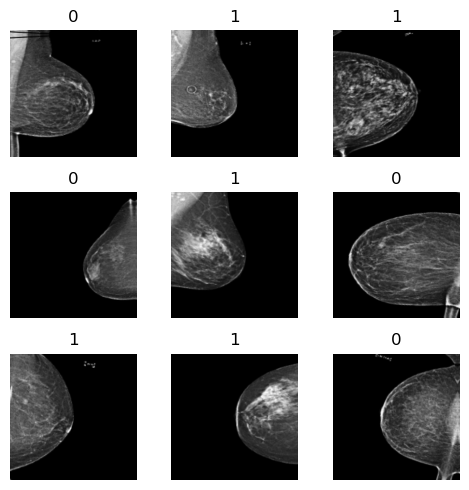

In [3]:
# Check to see augmentations were applied
plt.figure(figsize=(5, 5))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i]), cmap="gray")
        plt.title(int(labels[i]))
        plt.axis("off")

plt.tight_layout()
plt.show()

# Training

In [4]:
# Convert grayscale to rgb, ensure it is serializable to avoid loading problems later
@register_keras_serializable()
def grayscale_to_rgb(x):
    return tf.image.grayscale_to_rgb(x)

# Updated function that creates transfer models
def make_transfer_model(input_shape, model_name):
    
    # Choose the base model
    if model_name == "MobileNet":
        backbone = keras.applications.MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    elif model_name == "DenseNet":
        backbone = keras.applications.DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    elif model_name == "EfficientNet":
        backbone = keras.applications.EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )

    backbone.trainable = False

    # Convert grayscale to RGB
    inputs = keras.Input(shape=input_shape)
    x = layers.Lambda(grayscale_to_rgb, output_shape=(224, 224, 3))(inputs)

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    
    # L2 regularization and dropout layer should help with the overfitting issue
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x) 
    x = layers.Dropout(0.5)(x) 
    outputs = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(0.001))(x)

    return keras.Model(inputs, outputs, name=f"{model_name}_classifier")

In [5]:
# Create the model
EfficientNet = make_transfer_model((224,224,1), "EfficientNet")

In [6]:
# Calculate the class weights
train_labels = np.stack([y.numpy() for _, y in train_ds.unbatch()])

class_weights = dict(enumerate(class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)))

print(class_weights)

{0: 0.7558954748247291, 1: 1.4769613947696139}


2025-07-30 11:12:38.278573: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
optimizer = optimizers.Adam(learning_rate=0.001)

# Stop training if validation loss doesn't improve for 3 epochs
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

EfficientNet.compile(optimizer=optimizer,
                  loss="binary_crossentropy",
                  metrics=[keras.metrics.Recall(name="recall")])

efficient_history = EfficientNet.fit(
    train_ds,
    epochs=10,
    callbacks=callbacks,
    validation_data=valid_ds,
    class_weight=class_weights)

Epoch 1/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 102s 366ms/step - loss: 0.8583 - recall: 0.4486 - val_loss: 0.7674 - val_recall: 1.0000
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 85s 357ms/step - loss: 0.7365 - recall: 0.2711 - val_loss: 0.7199 - val_recall: 1.0000
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 83s 346ms/step - loss: 0.7126 - recall: 0.7506 - val_loss: 0.7068 - val_recall: 1.0000
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 81s 338ms/step - loss: 0.7011 - recall: 0.7147 - val_loss: 0.6998 - val_recall: 0.0000e+00
Epoch 5/10


2025-07-30 11:18:28.878598: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 2007160 bytes after encountering the first element of size 2007160 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


238/238 ━━━━━━━━━━━━━━━━━━━━ 122s 511ms/step - loss: 0.6968 - recall: 0.5829 - val_loss: 0.7011 - val_recall: 1.0000
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 116s 486ms/step - loss: 0.6945 - recall: 1.0000 - val_loss: 0.6983 - val_recall: 1.0000
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 108s 452ms/step - loss: 0.6951 - recall: 0.8881 - val_loss: 0.6972 - val_recall: 1.0000
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 92s 386ms/step - loss: 0.6907 - recall: 1.0000 - val_loss: 0.6963 - val_recall: 1.0000
Epoch 9/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - loss: 0.6902 - recall: 0.8887

2025-07-30 11:26:51.333537: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 2007080 bytes after encountering the first element of size 2007080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


238/238 ━━━━━━━━━━━━━━━━━━━━ 81s 339ms/step - loss: 0.6903 - recall: 0.8887 - val_loss: 0.7164 - val_recall: 1.0000
Epoch 10/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 85s 354ms/step - loss: 0.6893 - recall: 0.8964 - val_loss: 0.6946 - val_recall: 1.0000


In [8]:
# Save model
EfficientNet.save("efficientnet.keras")

# Save history
with open("history_efficientnet.pkl", "wb") as f:
    pickle.dump(efficient_history.history, f)